<a href="https://colab.research.google.com/github/annabashlakova/ECON3916-Statistical-Machine-Learning/blob/main/Assignment_3_The_Causal_Architecture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1.1
np.random.seed(42)
zeros = np.zeros (100)
tips = np.random.exponential(scale = 5.0, size = 150)
driver_tips = np.concatenate([zeros, tips])

In [4]:
# Step 1.2
n_iterations = 10000
bootstrap_medians = np.zeros(n_iterations)
for i in range (n_iterations):
  resample = np.random.choice(driver_tips, size = len(driver_tips), replace=True)
  bootstrap_medians[i] = np.median(resample)

# 95% interval
ci_lower, ci_upper = np.percentile(bootstrap_medians, [2.5, 97.5])

print(f"Observed Median: ${np.median(driver_tips):.4f}")
print(f"Bootstrap 95% CI: (${ci_lower:.4f}, ${ci_upper:.4f})")
print(f"Lower Margin: ${np.median(driver_tips) - ci_lower:.4f}")
print(f"Upper Margin: ${ci_upper - np.median(driver_tips):.4f}")

Observed Median: $0.7553
Bootstrap 95% CI: ($0.2817, $1.2990)
Lower Margin: $0.4736
Upper Margin: $0.5437


There is asymmetry as it stretched 0.47$ down and 0.54$ upwards, the upper side has more room as occasional large tips can move the median higher.But because the lowest nuber is zeros, it created a natural limit for how far down it can fall.

In [5]:
# Step 2.1
np.random.seed(42)
control = np.random.normal(loc=35, scale=5, size=500)
treatment = np.random.lognormal(mean=3.4, sigma=0.4, size=500)

observed_diff = np.mean(control) - np.mean(treatment)

print(f"Control Mean: {np.mean(control):.4f}min")
print(f"Treatment Mean: {np.mean(treatment):.4}min")
print(f"Observed Difference: {observed_diff:.4f}min")

Control Mean: 35.0342min
Treatment Mean: 32.77min
Observed Difference: 2.2650min


In [6]:
# Step 2.2
combined = np.concatenate([control, treatment])
n_iterations = 5_000
perm_diffs = np.zeros(n_iterations)

for i in range(n_iterations):
 shuffled = np.random.permutation(combined)
 perm_control = shuffled[:500]
 perm_treatment = shuffled[500:]
 perm_diffs[i] = np.mean(perm_control) - np.mean(perm_treatment)

 p_value = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))
 print(f"Observed Difference: {observed_diff:.4f}min")
 print(f"Permutation P-value: {p_value:.4f}")
 print(f"Significant (a=0.05): {p_value<0.05}")

Streaming output truncated to the last 5000 lines.
Permutation P-value: 0.0002
Significant (a=0.05): True
Observed Difference: 2.2650min
Permutation P-value: 0.0002
Significant (a=0.05): True
Observed Difference: 2.2650min
Permutation P-value: 0.0002
Significant (a=0.05): True
Observed Difference: 2.2650min
Permutation P-value: 0.0002
Significant (a=0.05): True
Observed Difference: 2.2650min
Permutation P-value: 0.0002
Significant (a=0.05): True
Observed Difference: 2.2650min
Permutation P-value: 0.0002
Significant (a=0.05): True
Observed Difference: 2.2650min
Permutation P-value: 0.0002
Significant (a=0.05): True
Observed Difference: 2.2650min
Permutation P-value: 0.0002
Significant (a=0.05): True
Observed Difference: 2.2650min
Permutation P-value: 0.0002
Significant (a=0.05): True
Observed Difference: 2.2650min
Permutation P-value: 0.0002
Significant (a=0.05): True
Observed Difference: 2.2650min
Permutation P-value: 0.0002
Significant (a=0.05): True
Observed Difference: 2.2650min
Per

In [7]:
# Step 3.1
import pandas as pd
df = pd.read_csv('swiftcart_loyalty.csv')
subscribers = df[df['subscriber'] == 1]['post_spend']
non_subscribers = df[df['subscriber']== 0] ['post_spend']

SDO = subscribers.mean() - non_subscribers.mean()

print(f"Subscribers Mean Post-Spend: ${subscribers.mean():.4f}")
print(f"Non-Subscribers Mean Post-Spend: ${non_subscribers.mean():.4f}")
print(f"Naive SDO: ${SDO:.4f}")
print(f"Naive Implied Lift: {(SDO/non_subscribers.mean()) * 100:.2f}%")

Subscribers Mean Post-Spend: $74.0436
Non-Subscribers Mean Post-Spend: $56.4729
Naive SDO: $17.5707
Naive Implied Lift: 31.11%


In [9]:
# Step 3.2
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

covariates = ['pre_spend', 'account_age', 'support_tickets']
X = df[covariates]
D = df['subscriber']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

logit = LogisticRegression()
logit.fit(X_scaled, D)
df['propensity_score'] = logit.predict_proba(X_scaled)[:,1]

treated = df[df['subscriber']==1].copy()
control = df[df['subscriber']==0].copy()

nn = NearestNeighbors(n_neighbors=1)
nn.fit(control[['propensity_score']])

distances, indices = nn.kneighbors(treated[['propensity_score']])
matched_control = control.iloc[indices.flatten()].copy()

ATT = treated['post_spend'].mean() - matched_control['post_spend'].mean()

print(f"Treated Mean Post-Spend: ${treated['post_spend'].mean():.4f}")
print(f"Matched Control Mean Post-Spend: ${matched_control['post_spend'].mean():.4f}")
print(f"Causal ATT: ${ATT:.4f}")
print(f"Naive SDO: ${SDO:.4f}")
print(f"Selection Bias Absorbed: ${SDO - ATT:.4f}")

Treated Mean Post-Spend: $74.0436
Matched Control Mean Post-Spend: $64.0241
Causal ATT: $10.0195
Naive SDO: $17.5707
Selection Bias Absorbed: $7.5512


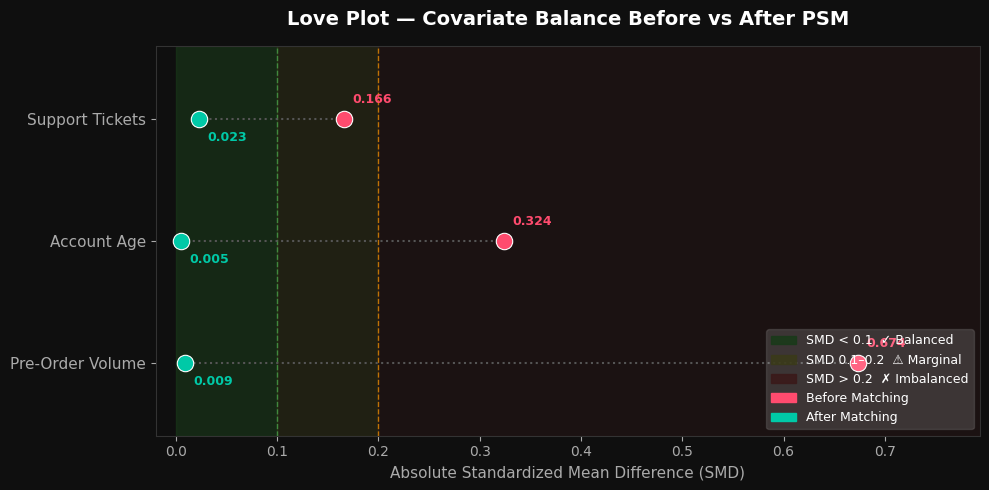

In [10]:
# Task 4.1 (AI)
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

covariates = ['pre_spend', 'account_age', 'support_tickets']

# ── Compute Standardized Mean Differences ──────────────────────────────────
def compute_smd(df, covariates, treatment_col='subscriber'):
    treated  = df[df[treatment_col] == 1]
    control  = df[df[treatment_col] == 0]
    smds = {}
    for col in covariates:
        mean_t  = treated[col].mean()
        mean_c  = control[col].mean()
        pooled_sd = np.sqrt((treated[col].var() + control[col].var()) / 2)
        smds[col] = abs(mean_t - mean_c) / pooled_sd
    return smds

# Build unmatched df and matched df
df_unmatched = df.copy()
df_matched   = pd.concat([treated.reset_index(drop=True),
                           matched_control.reset_index(drop=True)])

smd_before = compute_smd(df_unmatched, covariates)
smd_after  = compute_smd(df_matched,   covariates)

# ── Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0f0f0f')
ax.set_facecolor('#0f0f0f')

y_pos      = np.arange(len(covariates))
labels     = ['Pre-Order Volume', 'Account Age', 'Support Tickets']
before_vals = [smd_before[c] for c in covariates]
after_vals  = [smd_after[c]  for c in covariates]

# Reference bands
ax.axvspan(0,    0.1,  color='#1a3a1a', alpha=0.6, zorder=0)
ax.axvspan(0.1,  0.2,  color='#3a3a1a', alpha=0.4, zorder=0)
ax.axvspan(0.2,  0.8,  color='#3a1a1a', alpha=0.3, zorder=0)
ax.axvline(x=0.1, color='#4CAF50', linewidth=1, linestyle='--', alpha=0.7, zorder=1)
ax.axvline(x=0.2, color='#FF9800', linewidth=1, linestyle='--', alpha=0.7, zorder=1)

# Connecting lines
for i in range(len(covariates)):
    ax.plot([before_vals[i], after_vals[i]], [y_pos[i], y_pos[i]],
            color='#555555', linewidth=1.5, linestyle=':', zorder=2)

# Scatter points
ax.scatter(before_vals, y_pos, color='#FF4B6E', s=140, zorder=5,
           label='Before Matching', edgecolors='white', linewidth=0.8)
ax.scatter(after_vals,  y_pos, color='#00C9A7', s=140, zorder=5,
           label='After Matching',  edgecolors='white', linewidth=0.8)

# Annotations
for i, (b, a) in enumerate(zip(before_vals, after_vals)):
    ax.text(b + 0.008, y_pos[i] + 0.13, f'{b:.3f}',
            color='#FF4B6E', fontsize=9, fontweight='bold')
    ax.text(a + 0.008, y_pos[i] - 0.18, f'{a:.3f}',
            color='#00C9A7', fontsize=9, fontweight='bold')

# Axes formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, color='white', fontsize=11)
ax.set_xlabel('Absolute Standardized Mean Difference (SMD)', color='#aaaaaa', fontsize=11)
ax.set_title('Love Plot — Covariate Balance Before vs After PSM',
             color='white', fontsize=14, fontweight='bold', pad=15)
ax.tick_params(colors='#aaaaaa')
for spine in ax.spines.values():
    spine.set_edgecolor('#333333')

# Band legend
band_patches = [
    mpatches.Patch(color='#1a3a1a', alpha=0.9, label='SMD < 0.1  ✓ Balanced'),
    mpatches.Patch(color='#3a3a1a', alpha=0.9, label='SMD 0.1–0.2  ⚠ Marginal'),
    mpatches.Patch(color='#3a1a1a', alpha=0.9, label='SMD > 0.2  ✗ Imbalanced'),
]
dot_patches = [
    mpatches.Patch(color='#FF4B6E', label='Before Matching'),
    mpatches.Patch(color='#00C9A7', label='After Matching'),
]
ax.legend(handles=band_patches + dot_patches,
          loc='lower right', framealpha=0.15,
          labelcolor='white', fontsize=9)

ax.set_xlim(-0.02, max(before_vals) + 0.12)
ax.set_ylim(-0.6, len(covariates) - 0.4)
plt.tight_layout()
plt.savefig('love_plot.png', dpi=150, bbox_inches='tight',
            facecolor='#0f0f0f')
plt.show()